# Bayesian Panel Data Model

This notebook implements a Bayesian hierarchical panel model to analyze HALE and Life Expectancy gender gaps using both temporal variation (2000-2019) and cross-country variation simultaneously.

## Overview

The panel data approach provides more statistical power and allows us to model how relationships between indicators and gender gaps evolve over time, while accounting for country-specific characteristics.

**Model Structure:**
- Bayesian hierarchical model with country-level random intercepts
- Shared slopes for all predictors (same across all countries)
- Uses both within-country and between-country variation
- Controls for time-invariant country-level factors

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

from utils import (
    decorate, underride, configure_plot_style, AIBM_COLORS,
    load_and_inventory, compute_gender_gap, get_oecd,
    load_ihme_indicator, column_name_mapping, oecd_codes,
    write_html_table
)

configure_plot_style()

## Data Preparation

### Helper Function: Compute Temporal Gaps

We need a function that preserves all years (not just most recent) to create panel data:

In [3]:
def compute_temporal_gaps(df, value_col, sexes=['Male', 'Female']):
    """
    Compute gender gaps for all years (not just most recent).
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with Year, Code, Sex, and value_col columns
    value_col : str
        Name of the value column
    sexes : list
        List of sex values to compare
        
    Returns
    -------
    df_gaps : pandas.DataFrame
        DataFrame with Gap and Mid columns for all years
    """
    return compute_gender_gap(df, value_col, sexes)

### Load Target Variables

#### HALE Data

In [4]:
filename = '../data/who_hale_data.csv'
hale, years = load_and_inventory(filename)

(11100, 10)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [5]:
# Map sex codes to standard names
sex_mapping = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male'}
hale['Sex'] = hale['Sex'].replace(sex_mapping)

In [6]:
# Compute gaps for all years (preserve temporal structure)
# Note: compute_gender_gap computes Gap as Male - Female, but we want Female - Male
hale_temporal = compute_temporal_gaps(hale, 'HALE_Years', sexes=['Male', 'Female'])
# Calculate gap as Female - Male (positive gap means women live longer)
# Gap_HALE_Years is Male - Female, so we negate it
hale_temporal['HALE_gap'] = -hale_temporal['Gap_HALE_Years']
hale_temporal.head()

,Code,Year,HALE_Years_Male,HALE_Years_Female,Gap_HALE_Years,Mid_HALE_Years,Country,HALE_gap
0,AFG,2000,45.943669,46.154851,-0.211182,46.049260,Afghanistan,0.211182
1,AFG,2001,45.989073,46.284875,-0.295802,46.136974,Afghanistan,0.295802
2,AFG,2002,47.407615,46.994510,0.413105,47.201063,Afghanistan,-0.413105
3,AFG,2003,48.291904,47.702906,0.588998,47.997405,Afghanistan,-0.588998
4,AFG,2004,48.637754,48.050686,0.587069,48.344220,Afghanistan,-0.587069


#### Life Expectancy Data

In [7]:
filename = '../data/who_life_expectancy_data.csv'
le, years = load_and_inventory(filename)

(11100, 10)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [8]:
# Map sex codes to standard names
le['Sex'] = le['Sex'].replace(sex_mapping)

In [9]:
# Compute gaps for all years (preserve temporal structure)
# Note: compute_gender_gap computes Gap as Male - Female, but we want Female - Male
le_temporal = compute_temporal_gaps(le, 'LifeExpectancy_Years', sexes=['Male', 'Female'])
# Calculate gap as Female - Male (positive gap means women live longer)
# Gap_LifeExpectancy_Years is Male - Female, so we negate it
le_temporal['LE_gap'] = -le_temporal['Gap_LifeExpectancy_Years']
le_temporal.head()

,Code,Year,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,Gap_LifeExpectancy_Years,Mid_LifeExpectancy_Years,Country,LE_gap
0,AFG,2000,53.249991,54.429579,-1.179588,53.839785,Afghanistan,1.179588
1,AFG,2001,53.284639,54.570059,-1.285419,53.927349,Afghanistan,1.285419
2,AFG,2002,54.921993,55.401586,-0.479593,55.161789,Afghanistan,0.479593
3,AFG,2003,55.949458,56.242837,-0.293379,56.096147,Afghanistan,0.293379
4,AFG,2004,56.329965,56.647472,-0.317507,56.488719,Afghanistan,0.317507


### Load Predictor Indicators

We'll load all indicators used in the final model. For panel analysis, we need to preserve all years, so we use `compute_temporal_gaps` instead of `summarize_gap`.

#### Helper Function for Loading IHME Indicators

In [10]:
def load_ihme_indicator_temporal(base_filename, value_col_name, indicator_code, indicator_name):
    """
    Load IHME indicator data and compute temporal gaps for all years.
    
    Parameters
    ----------
    base_filename : str
        Base filename without path, sex suffix, or extension (e.g., 'ihme_alcohol_use_disorders_deaths')
    value_col_name : str
        Name of the value column (e.g., 'AlcoholUseDisordersDeathRate')
    indicator_code : str
        Indicator code (e.g., 'IHME_ALCOHOL_USE_DISORDERS')
    indicator_name : str
        Human-readable indicator name
        
    Returns
    -------
    df_temporal : pandas.DataFrame
        DataFrame with temporal gaps computed for all years
    """
    filename_male = f'../data/{base_filename}_male.csv'
    filename_female = f'../data/{base_filename}_female.csv'
    df = load_ihme_indicator(
        filename_male, filename_female,
        value_col_name=value_col_name,
        indicator_code=indicator_code,
        indicator_name=indicator_name,
        min_year=2000,
        max_year=2019
    )
    df = df.rename(columns=column_name_mapping)
    col = column_name_mapping.get(value_col_name, value_col_name)
    df_temporal = compute_temporal_gaps(df, col, sexes=['Male', 'Female'])
    return df_temporal

#### Alcohol Use Disorders (IHME)

In [11]:
alcohol_temporal = load_ihme_indicator_temporal(
    'ihme_alcohol_use_disorders_deaths',
    'AlcoholUseDisordersDeathRate',
    'IHME_ALCOHOL_USE_DISORDERS',
    'Alcohol use disorders, death rate per 100,000'
)
alcohol_temporal.head()

,Code,Year,Alcohol_Male,Alcohol_Female,Gap_Alcohol,Mid_Alcohol,Country
0,AUS,2000.0,2.734867,0.631488,2.103379,1.683177,Australia
1,AUS,2001.0,2.651414,0.616363,2.035051,1.633888,Australia
2,AUS,2002.0,2.712614,0.672539,2.040075,1.692577,Australia
3,AUS,2003.0,2.686314,0.680933,2.005382,1.683623,Australia
4,AUS,2004.0,2.626829,0.704165,1.922664,1.665497,Australia


#### Self-Harm (IHME)

In [12]:
self_harm_temporal = load_ihme_indicator_temporal(
    'ihme_self_harm_deaths',
    'SelfHarmDeathRate',
    'IHME_SELF_HARM',
    'Self-harm (suicide), death rate per 100,000'
)
self_harm_temporal.head()

,Code,Year,Suicide_Male,Suicide_Female,Gap_Suicide,Mid_Suicide,Country
0,AUS,2000.0,21.632300,5.627537,16.004763,13.629919,Australia
1,AUS,2001.0,20.813040,5.677859,15.135181,13.245450,Australia
2,AUS,2002.0,19.557416,5.484698,14.072718,12.521057,Australia
3,AUS,2003.0,18.599332,5.150209,13.449123,11.874770,Australia
4,AUS,2004.0,18.148308,4.923421,13.224887,11.535865,Australia


#### Interpersonal Violence (IHME)

In [13]:
interpersonal_violence_temporal = load_ihme_indicator_temporal(
    'ihme_interpersonal_violence_deaths',
    'InterpersonalViolenceDeathRate',
    'IHME_INTERPERSONAL_VIOLENCE',
    'Interpersonal violence (homicide), death rate per 100,000'
)
interpersonal_violence_temporal.head()

,Code,Year,Homicide_Male,Homicide_Female,Gap_Homicide,Mid_Homicide,Country
0,AUS,2000.0,2.246983,1.220574,1.026409,1.733778,Australia
1,AUS,2001.0,2.213900,1.155846,1.058054,1.684873,Australia
2,AUS,2002.0,2.095225,1.080767,1.014458,1.587996,Australia
3,AUS,2003.0,1.880337,0.889872,0.990465,1.385104,Australia
4,AUS,2004.0,1.495477,0.758536,0.736941,1.127007,Australia


#### Road Injuries (IHME)

In [14]:
road_injuries_temporal = load_ihme_indicator_temporal(
    'ihme_road_injuries_deaths',
    'RoadInjuriesDeathRate',
    'IHME_ROAD_INJURIES',
    'Road injuries (road traffic crashes), death rate per 100,000'
)
road_injuries_temporal.head()

,Code,Year,RoadTraffic_Male,RoadTraffic_Female,Gap_RoadTraffic,Mid_RoadTraffic,Country
0,AUS,2000.0,15.184325,6.084094,9.100231,10.634210,Australia
1,AUS,2001.0,14.674288,5.782579,8.891709,10.228433,Australia
2,AUS,2002.0,13.989668,5.545272,8.444396,9.767470,Australia
3,AUS,2003.0,13.230099,5.210589,8.019510,9.220344,Australia
4,AUS,2004.0,12.930886,4.897544,8.033342,8.914215,Australia


#### Cardiovascular Disease (IHME)

In [15]:
cardiovascular_temporal = load_ihme_indicator_temporal(
    'ihme_cardiovascular_deaths',
    'CardioDeathRate',
    'IHME_CARDIOVASCULAR',
    'Cardiovascular diseases, death rate per 100,000'
)
cardiovascular_temporal.head()

,Code,Year,Cardiovascular_Male,Cardiovascular_Female,Gap_Cardiovascular,Mid_Cardiovascular,Country
0,AUS,2000.0,251.531993,259.494605,-7.962612,255.513299,Australia
1,AUS,2001.0,245.860127,253.477767,-7.617639,249.668947,Australia
2,AUS,2002.0,245.223115,253.122588,-7.899473,249.172852,Australia
3,AUS,2003.0,236.409743,244.429433,-8.019690,240.419588,Australia
4,AUS,2004.0,228.397267,235.278983,-6.881717,231.838125,Australia


#### Diabetes (IHME)

In [16]:
diabetes_temporal = load_ihme_indicator_temporal(
    'ihme_diabetes_deaths',
    'DiabetesDeathRate',
    'IHME_DIABETES_TYPE2',
    'Diabetes mellitus type 2, death rate per 100,000'
)
diabetes_temporal.head()

,Code,Year,Diabetes_Male,Diabetes_Female,Gap_Diabetes,Mid_Diabetes,Country
0,AUS,2000.0,16.568642,14.248627,2.320015,15.408635,Australia
1,AUS,2001.0,17.037716,14.344688,2.693028,15.691202,Australia
2,AUS,2002.0,17.960180,14.975359,2.984820,16.467769,Australia
3,AUS,2003.0,18.379621,15.525666,2.853954,16.952644,Australia
4,AUS,2004.0,18.334611,16.080445,2.254167,17.207528,Australia


#### Neoplasms (IHME)

In [17]:
neoplasms_temporal = load_ihme_indicator_temporal(
    'ihme_neoplasms_deaths',
    'NeoplasmsDeathRate',
    'IHME_NEOPLASMS',
    'Neoplasms (cancer), death rate per 100,000'
)
neoplasms_temporal.head()

,Code,Year,Neoplasms_Male,Neoplasms_Female,Gap_Neoplasms,Mid_Neoplasms,Country
0,AUS,2000.0,229.808667,174.372594,55.436073,202.090630,Australia
1,AUS,2001.0,230.943004,176.862341,54.080663,203.902673,Australia
2,AUS,2002.0,233.465215,179.519671,53.945544,206.492443,Australia
3,AUS,2003.0,232.827329,178.595845,54.231484,205.711587,Australia
4,AUS,2004.0,233.886844,177.584662,56.302182,205.735753,Australia


#### Chronic Respiratory Disease (IHME)

In [18]:
chronic_respiratory_temporal = load_ihme_indicator_temporal(
    'ihme_chronic_respiratory_deaths',
    'ChronicRespiratoryDeathRate',
    'IHME_CHRONIC_RESPIRATORY',
    'Chronic respiratory diseases, death rate per 100,000'
)
chronic_respiratory_temporal.head()

,Code,Year,ChronicRespiratory_Male,ChronicRespiratory_Female,Gap_ChronicRespiratory,Mid_ChronicRespiratory,Country
0,AUS,2000.0,47.317193,33.416935,13.900258,40.367064,Australia
1,AUS,2001.0,46.003680,33.538075,12.465605,39.770878,Australia
2,AUS,2002.0,46.598934,34.771695,11.827239,40.685314,Australia
3,AUS,2003.0,44.267105,34.102959,10.164146,39.185032,Australia
4,AUS,2004.0,42.134910,33.381971,8.752940,37.758441,Australia


#### Liver Disease (IHME)

In [19]:
liver_disease_temporal = load_ihme_indicator_temporal(
    'ihme_liver_disease_deaths',
    'LiverDiseaseDeathRate',
    'IHME_LIVER_DISEASE',
    'Cirrhosis and other chronic liver diseases, death rate per 100,000'
)
liver_disease_temporal.head()

,Code,Year,LiverDisease_Male,LiverDisease_Female,Gap_LiverDisease,Mid_LiverDisease,Country
0,AUS,2000.0,9.277966,4.125954,5.152012,6.701960,Australia
1,AUS,2001.0,9.433355,4.028933,5.404421,6.731144,Australia
2,AUS,2002.0,9.887432,4.357130,5.530302,7.122281,Australia
3,AUS,2003.0,10.141958,4.273111,5.868847,7.207535,Australia
4,AUS,2004.0,10.222984,4.275616,5.947368,7.249300,Australia


#### Unintentional Injuries (IHME)

In [20]:
unintentional_injuries_temporal = load_ihme_indicator_temporal(
    'ihme_unintentional_injuries_deaths',
    'UnintentionalInjuriesDeathRate',
    'IHME_UNINTENTIONAL_INJURIES',
    'Unintentional injuries, death rate per 100,000'
)
unintentional_injuries_temporal.head()

,Code,Year,UnintentionalInjury_Male,UnintentionalInjury_Female,Gap_UnintentionalInjury,Mid_UnintentionalInjury,Country
0,AUS,2000.0,14.719270,12.032874,2.686396,13.376072,Australia
1,AUS,2001.0,14.106178,11.824066,2.282112,12.965122,Australia
2,AUS,2002.0,15.206234,12.696670,2.509564,13.951452,Australia
3,AUS,2003.0,15.927738,13.010010,2.917728,14.468874,Australia
4,AUS,2004.0,16.703760,13.977934,2.725826,15.340847,Australia


### Merge All Data into Panel Format

Now we'll merge all indicators into a single panel dataset with one row per country-year:

In [21]:
# Start with HALE gap as base
panel_df = hale_temporal[['Code', 'Year', 'HALE_gap']].copy()
panel_df = panel_df.rename(columns={'Code': 'country'})

# Add Life Expectancy gap
le_panel = le_temporal[['Code', 'Year', 'LE_gap']].copy()
le_panel = le_panel.rename(columns={'Code': 'country'})
panel_df = panel_df.merge(le_panel, on=['country', 'Year'], how='outer')

# Function to merge predictor indicators
def merge_predictor(df_temporal, indicator_name):
    """Merge a predictor indicator into the panel dataset."""
    # Select relevant columns (Code, Year, Mid_*, Gap_*)
    cols_to_merge = ['Code', 'Year']
    mid_col = [c for c in df_temporal.columns if c.startswith('Mid_')]
    gap_col = [c for c in df_temporal.columns if c.startswith('Gap_')]
    cols_to_merge.extend(mid_col)
    cols_to_merge.extend(gap_col)
    
    df_subset = df_temporal[cols_to_merge].copy()
    df_subset = df_subset.rename(columns={'Code': 'country'})
    return df_subset

# Merge all predictors
predictors_to_merge = [
    (alcohol_temporal, 'Alcohol'),
    (self_harm_temporal, 'SelfHarm'),
    (interpersonal_violence_temporal, 'InterpersonalViolence'),
    (road_injuries_temporal, 'RoadInjuries'),
    (cardiovascular_temporal, 'Cardiovascular'),
    (diabetes_temporal, 'Diabetes'),
    (neoplasms_temporal, 'Neoplasms'),
    (chronic_respiratory_temporal, 'ChronicRespiratory'),
    (liver_disease_temporal, 'LiverDisease'),
    (unintentional_injuries_temporal, 'UnintentionalInjuries'),
]

for df_temp, name in predictors_to_merge:
    df_merge = merge_predictor(df_temp, name)
    panel_df = panel_df.merge(df_merge, on=['country', 'Year'], how='outer')
    print(f"Merged {name}: {len(df_merge)} rows")

print(f"\nFinal panel dataset shape: {panel_df.shape}")
print(f"Columns: {list(panel_df.columns)}")

Merged Alcohol: 760 rows
Merged SelfHarm: 760 rows
Merged InterpersonalViolence: 760 rows
Merged RoadInjuries: 760 rows
Merged Cardiovascular: 760 rows
Merged Diabetes: 760 rows
Merged Neoplasms: 760 rows
Merged ChronicRespiratory: 760 rows
Merged LiverDisease: 760 rows
Merged UnintentionalInjuries: 760 rows

Final panel dataset shape: (3700, 24)
Columns: ['country', 'Year', 'HALE_gap', 'LE_gap', 'Mid_Alcohol', 'Gap_Alcohol', 'Mid_Suicide', 'Gap_Suicide', 'Mid_Homicide', 'Gap_Homicide', 'Mid_RoadTraffic', 'Gap_RoadTraffic', 'Mid_Cardiovascular', 'Gap_Cardiovascular', 'Mid_Diabetes', 'Gap_Diabetes', 'Mid_Neoplasms', 'Gap_Neoplasms', 'Mid_ChronicRespiratory', 'Gap_ChronicRespiratory', 'Mid_LiverDisease', 'Gap_LiverDisease', 'Mid_UnintentionalInjury', 'Gap_UnintentionalInjury']


In [22]:
# Filter to OECD countries
panel_df = panel_df[panel_df['country'].isin(oecd_codes)].copy()
print(f"After filtering to OECD: {panel_df.shape}")

# Filter to years 2000-2019
panel_df = panel_df[(panel_df['Year'] >= 2000) & (panel_df['Year'] <= 2019)].copy()
print(f"After filtering to 2000-2019: {panel_df.shape}")

# Sort by country and year
panel_df = panel_df.sort_values(['country', 'Year']).reset_index(drop=True)
panel_df.head()

After filtering to OECD: (760, 24)
After filtering to 2000-2019: (760, 24)


,country,Year,HALE_gap,LE_gap,Mid_Alcohol,Gap_Alcohol,Mid_Suicide,Gap_Suicide,Mid_Homicide,Gap_Homicide,...,Mid_Diabetes,Gap_Diabetes,Mid_Neoplasms,Gap_Neoplasms,Mid_ChronicRespiratory,Gap_ChronicRespiratory,Mid_LiverDisease,Gap_LiverDisease,Mid_UnintentionalInjury,Gap_UnintentionalInjury
0,AUS,2000,2.385148,5.117413,1.683177,2.103379,13.629919,16.004763,1.733778,1.026409,...,15.408635,2.320015,202.090630,55.436073,40.367064,13.900258,6.701960,5.152012,13.376072,2.686396
1,AUS,2001,2.287445,5.025503,1.633888,2.035051,13.245450,15.135181,1.684873,1.058054,...,15.691202,2.693028,203.902673,54.080663,39.770878,12.465605,6.731144,5.404421,12.965122,2.282112
2,AUS,2002,2.050956,4.759476,1.692577,2.040075,12.521057,14.072718,1.587996,1.014458,...,16.467769,2.984820,206.492443,53.945544,40.685314,11.827239,7.122281,5.530302,13.951452,2.509564
3,AUS,2003,1.982985,4.698802,1.683623,2.005382,11.874770,13.449123,1.385104,0.990465,...,16.952644,2.853954,205.711587,54.231484,39.185032,10.164146,7.207535,5.868847,14.468874,2.917728
4,AUS,2004,1.906233,4.627694,1.665497,1.922664,11.535865,13.224887,1.127007,0.736941,...,17.207528,2.254167,205.735753,56.302182,37.758441,8.752940,7.249300,5.947368,15.340847,2.725826


In [23]:
# Check for missing data
print("Missing data summary:")
print(panel_df.isnull().sum().sum(), "total missing values")
print("\nMissing values by column:")
missing_by_col = panel_df.isnull().sum()
print(missing_by_col[missing_by_col > 0])

Missing data summary:
0 total missing values

Missing values by column:
Series([], dtype: int64)


In [24]:
# Check data coverage
print("Data coverage:")
print(f"Countries: {panel_df['country'].nunique()}")
print(f"Years: {sorted(panel_df['Year'].unique())}")
print(f"Country-year combinations: {len(panel_df)}")
print(f"\nExpected (if complete): {len(oecd_codes)} countries × 20 years = {len(oecd_codes) * 20}")

Data coverage:
Countries: 38
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Country-year combinations: 760

Expected (if complete): 38 countries × 20 years = 760


## Prepare Panel Data for Modeling

Now we'll use the `prepare_panel_data` function to standardize predictors and center targets:

In [25]:
def prepare_panel_data(df, predictor_cols, target_col):
    """
    Prepare panel data for Bayesian modeling.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Long-format DataFrame with columns:
        - 'country' (str)
        - 'year' (int)
        - target_col (float, HALE_gap or LE_gap in years)
        - predictor_cols (float)
    
    Returns
    -------
    data_dict : dict
        Dictionary with:
            X          : (N, P) ndarray of standardized predictors
            y_centered : (N,) ndarray of centered target
            country_idx: (N,) int array in [0, n_country-1]
            year_idx   : (N,) int array in [0, n_year-1]
            coords     : dict for PyMC Model(coords=...)
            meta       : dict with means/SDs for later use
    """
    df = df.copy()
    
    # Unique levels
    countries = np.sort(df["country"].unique())
    years = np.sort(df["year"].unique())
    predictors = list(predictor_cols)
    
    country_indexer = {c: i for i, c in enumerate(countries)}
    year_indexer = {y: i for i, y in enumerate(years)}
    
    df["country_idx"] = df["country"].map(country_indexer)
    df["year_idx"] = df["year"].map(year_indexer)
    
    # Extract raw matrices/vectors
    X_raw = df[predictor_cols].to_numpy(dtype=float)
    y_raw = df[target_col].to_numpy(dtype=float)
    country_idx = df["country_idx"].to_numpy(dtype=int)
    year_idx = df["year_idx"].to_numpy(dtype=int)
    
    # Standardize predictors across all country–year rows
    X_mean = X_raw.mean(axis=0)
    X_std = X_raw.std(axis=0, ddof=0)
    # Guard against any zero variance columns
    X_std_safe = np.where(X_std == 0, 1.0, X_std)
    X = (X_raw - X_mean) / X_std_safe
    
    # Center target (keep units in years)
    y_mean = y_raw.mean()
    y_centered = y_raw - y_mean
    
    N, P = X.shape
    
    coords = {
        "obs": np.arange(N),
        "country": countries,
        "year": years,
        "predictor": predictors,
    }
    
    data_dict = {
        "X": X,
        "y_centered": y_centered,
        "country_idx": country_idx,
        "year_idx": year_idx,
        "coords": coords,
        "meta": {
            "X_mean": X_mean,
            "X_std": X_std_safe,
            "y_mean": y_mean,
            "countries": countries,
            "years": years,
            "predictors": predictors,
        },
    }
    
    return data_dict

In [26]:
# Prepare predictor columns (Mid and Gap for each indicator)
predictor_cols = [col for col in panel_df.columns 
                  if col.startswith('Mid_') or col.startswith('Gap_')]
print(f"Number of predictors: {len(predictor_cols)}")
print(f"Predictors: {predictor_cols}")

Number of predictors: 20
Predictors: ['Mid_Alcohol', 'Gap_Alcohol', 'Mid_Suicide', 'Gap_Suicide', 'Mid_Homicide', 'Gap_Homicide', 'Mid_RoadTraffic', 'Gap_RoadTraffic', 'Mid_Cardiovascular', 'Gap_Cardiovascular', 'Mid_Diabetes', 'Gap_Diabetes', 'Mid_Neoplasms', 'Gap_Neoplasms', 'Mid_ChronicRespiratory', 'Gap_ChronicRespiratory', 'Mid_LiverDisease', 'Gap_LiverDisease', 'Mid_UnintentionalInjury', 'Gap_UnintentionalInjury']


In [27]:
# Rename columns to match function expectations (country, year)
panel_df_model = panel_df.rename(columns={'country': 'country', 'Year': 'year'})

# Prepare data for HALE gap model
data_hale = prepare_panel_data(
    panel_df_model,
    predictor_cols=predictor_cols,
    target_col='HALE_gap'
)

print(f"HALE model data:")
print(f"  Observations: {data_hale['X'].shape[0]}")
print(f"  Predictors: {data_hale['X'].shape[1]}")
print(f"  Countries: {len(data_hale['coords']['country'])}")
print(f"  Years: {len(data_hale['coords']['year'])}")

HALE model data:
  Observations: 760
  Predictors: 20
  Countries: 38
  Years: 20


In [28]:
# Prepare data for Life Expectancy gap model
data_le = prepare_panel_data(
    panel_df_model,
    predictor_cols=predictor_cols,
    target_col='LE_gap'
)

print(f"Life Expectancy model data:")
print(f"  Observations: {data_le['X'].shape[0]}")
print(f"  Predictors: {data_le['X'].shape[1]}")
print(f"  Countries: {len(data_le['coords']['country'])}")
print(f"  Years: {len(data_le['coords']['year'])}")

Life Expectancy model data:
  Observations: 760
  Predictors: 20
  Countries: 38
  Years: 20


## Build Bayesian Model Function

Now we'll define the function to build the Bayesian hierarchical model with random intercepts:

In [29]:
def build_random_intercept_panel_model(data):
    """
    Build a Bayesian hierarchical panel model with:
      - Random intercepts by country
      - Shared slopes for all predictors
      - Centered outcome y (HALE_gap or LE_gap) in years
      - Standardized predictors
    
    Parameters
    ----------
    data : dict
        Output of prepare_panel_data(...)
    
    Returns
    -------
    model : pymc.Model
        PyMC model object
    """
    X = data["X"]
    y_centered = data["y_centered"]
    country_idx = data["country_idx"]
    year_idx = data["year_idx"]   # Not used in this first version, but wired in for future extensions
    coords = data["coords"]
    
    with pm.Model(coords=coords) as model:
        # Register index arrays and design matrix as Data
        country_idx_data = pm.Data("country_idx", country_idx, dims="obs")
        year_idx_data = pm.Data("year_idx", year_idx, dims="obs")  # placeholder for later year effects
        X_data = pm.Data("X", X, dims=("obs", "predictor"))
        y_data = pm.Data("y", y_centered, dims="obs")
        
        # Hyperpriors for country intercepts
        mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1.0)
        
        # Country-specific random intercepts
        alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, dims="country")
        alpha = pm.Deterministic(
            "alpha",
            mu_alpha + alpha_raw * sigma_alpha,
            dims="country",
        )
        
        # Global slopes for standardized predictors
        beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="predictor")
        
        # Residual standard deviation (on y_centered scale, i.e., years)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        
        # Linear predictor: random intercept by country + global slopes
        # Use pm.Data objects in the graph for explicit dependencies
        mu = pm.Deterministic(
            "mu",
            alpha[country_idx_data] + pm.math.dot(X_data, beta),
            dims="obs"
        )
        
        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data, dims="obs")
    
    return model

## HALE Gap Model

### Build Model

In [30]:
# Build model for HALE gap
model_hale = build_random_intercept_panel_model(data_hale)
model_hale

   mu_alpha ~ Normal(0, 5)
sigma_alpha ~ HalfNormal(0, 1)
  alpha_raw ~ Normal(0, 1)
       beta ~ Normal(0, 1)
      sigma ~ HalfNormal(0, 1)
      alpha ~ Deterministic(f(alpha_raw, mu_alpha, sigma_alpha))
         mu ~ Deterministic(f(beta, alpha_raw, mu_alpha, sigma_alpha))
      y_obs ~ Normal(mu, sigma)

### Sample from Posterior

In [31]:
# Sample from HALE model
with model_hale:
    trace_hale = pm.sample(
        nuts_sampler='nutpie'
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.14,127
,2000,0,0.13,127
,2000,0,0.11,255
,2000,0,0.12,127


### Model Diagnostics

Check convergence and sampling quality:

In [32]:
# HALE model diagnostics
az.summary(trace_hale, var_names=["mu_alpha", "sigma_alpha", "sigma", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.001,0.089,-0.178,0.161,0.002,0.002,1926.0,1970.0,1.00
sigma_alpha,0.529,0.070,0.397,0.655,0.002,0.001,1742.0,2376.0,1.01
sigma,0.189,0.005,0.179,0.198,0.000,0.000,3254.0,2328.0,1.00
beta[Mid_Alcohol],-0.172,0.175,-0.491,0.163,0.004,0.003,1863.0,2323.0,1.00
beta[Gap_Alcohol],0.323,0.154,0.021,0.606,0.004,0.002,1888.0,2404.0,1.00
beta[Mid_Suicide],0.216,0.085,0.052,0.371,0.001,0.001,3387.0,2802.0,1.00
beta[Gap_Suicide],0.297,0.092,0.128,0.471,0.002,0.001,3574.0,3066.0,1.00
beta[Mid_Homicide],-1.174,0.325,-1.808,-0.604,0.010,0.007,1003.0,1267.0,1.00
beta[Gap_Homicide],1.512,0.328,0.936,2.161,0.010,0.007,999.0,1266.0,1.00
beta[Mid_RoadTraffic],0.574,0.078,0.431,0.717,0.002,0.001,2644.0,2957.0,1.00


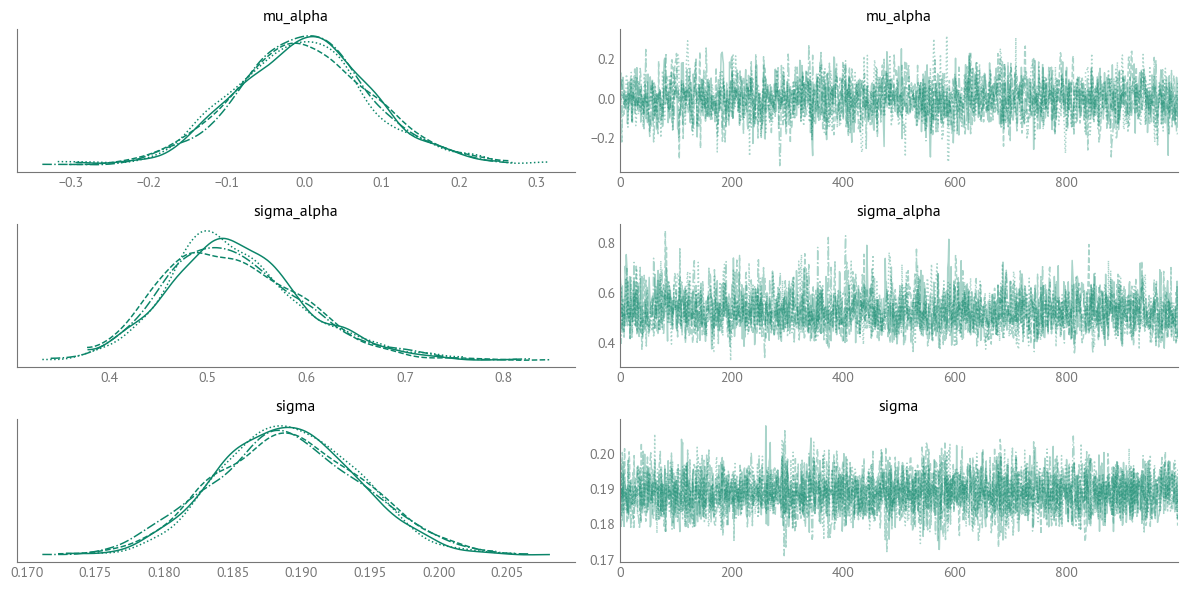

In [33]:
# Plot trace plots for key parameters (HALE)
az.plot_trace(trace_hale, var_names=["mu_alpha", "sigma_alpha", "sigma"], compact=True)
plt.tight_layout()
plt.show()

### Posterior Analysis

Extract and analyze posterior distributions:

In [34]:
# Extract posterior means and credible intervals for beta coefficients (HALE)
beta_summary_hale = az.summary(trace_hale, var_names=["beta"])
beta_summary_hale.index = data_hale["meta"]["predictors"]
beta_summary_hale

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Mid_Alcohol,-0.172,0.175,-0.491,0.163,0.004,0.003,1863.0,2323.0,1.0
Gap_Alcohol,0.323,0.154,0.021,0.606,0.004,0.002,1888.0,2404.0,1.0
Mid_Suicide,0.216,0.085,0.052,0.371,0.001,0.001,3387.0,2802.0,1.0
Gap_Suicide,0.297,0.092,0.128,0.471,0.002,0.001,3574.0,3066.0,1.0
Mid_Homicide,-1.174,0.325,-1.808,-0.604,0.010,0.007,1003.0,1267.0,1.0
Gap_Homicide,1.512,0.328,0.936,2.161,0.010,0.007,999.0,1266.0,1.0
Mid_RoadTraffic,0.574,0.078,0.431,0.717,0.002,0.001,2644.0,2957.0,1.0
Gap_RoadTraffic,-0.214,0.082,-0.357,-0.054,0.001,0.001,3523.0,2917.0,1.0
Mid_Cardiovascular,0.467,0.054,0.360,0.564,0.001,0.001,4100.0,2489.0,1.0
Gap_Cardiovascular,-0.058,0.028,-0.112,-0.009,0.000,0.000,4534.0,3583.0,1.0


In [35]:
# Write beta coefficients table to HTML
beta_summary_hale_formatted = beta_summary_hale.reset_index().rename(columns={'index': 'Predictor'})
write_html_table(beta_summary_hale_formatted, 'jb/tables/beta_coefficients_hale.html')

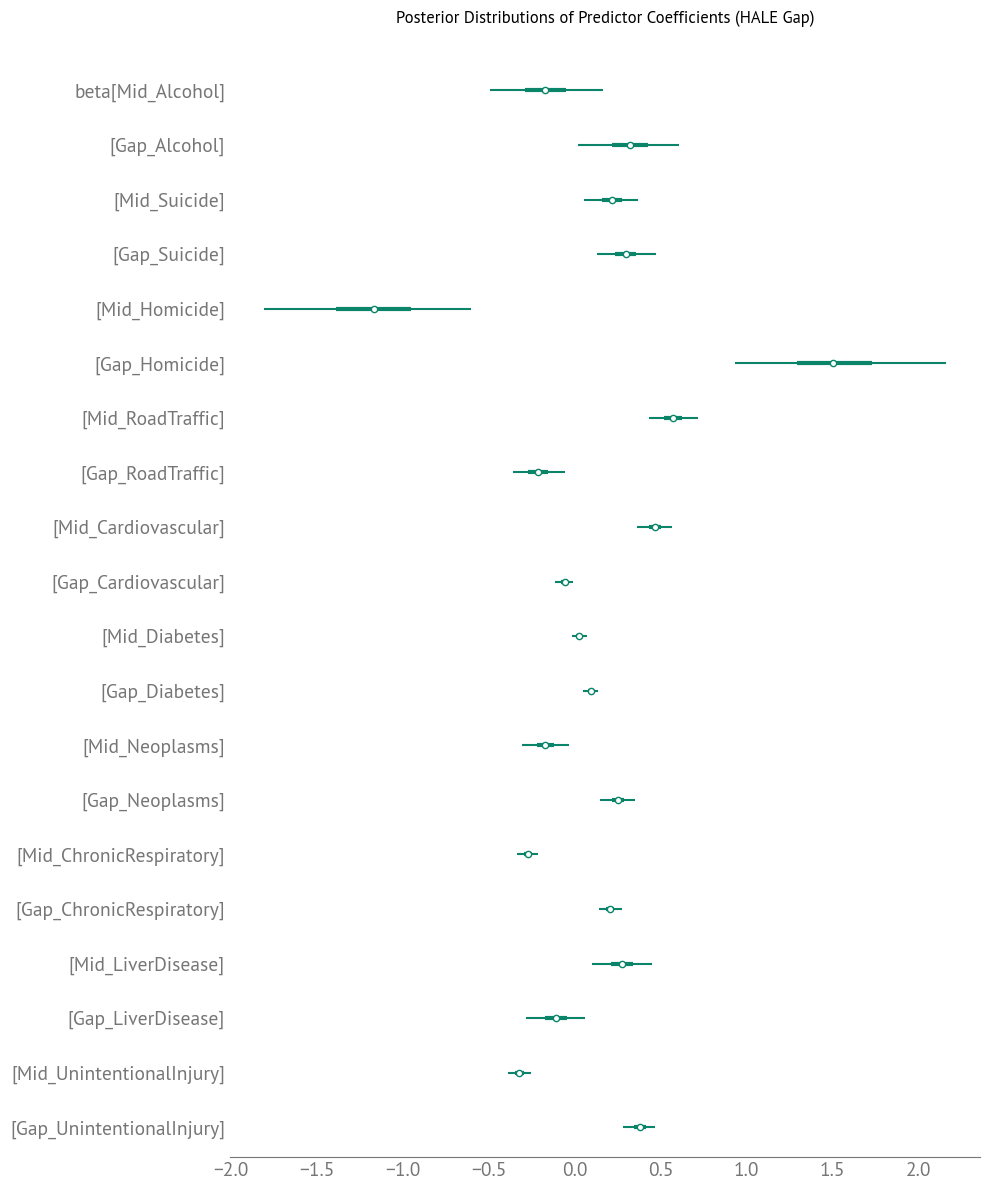

In [36]:
# Plot posterior distributions of beta coefficients (HALE)
az.plot_forest(trace_hale, var_names=["beta"], combined=True, figsize=(10, 12))
plt.title("Posterior Distributions of Predictor Coefficients (HALE Gap)")
plt.tight_layout()
plt.show()

In [37]:
# Extract posterior means and credible intervals for alpha coefficients (country intercepts, HALE)
alpha_summary_hale = az.summary(trace_hale, var_names=["alpha"])
alpha_summary_hale.index = data_hale["meta"]["countries"]
alpha_summary_hale

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
AUS,-0.222,0.063,-0.346,-0.111,0.001,0.001,4449.0,3795.0,1.0
AUT,-0.617,0.073,-0.759,-0.485,0.001,0.001,5253.0,3610.0,1.0
BEL,-0.189,0.103,-0.381,0.005,0.001,0.002,4864.0,3267.0,1.0
CAN,0.011,0.079,-0.150,0.151,0.001,0.001,3675.0,3251.0,1.0
CHE,-0.135,0.076,-0.286,0.001,0.001,0.001,4359.0,3554.0,1.0
CHL,-0.684,0.097,-0.869,-0.510,0.002,0.001,3862.0,3343.0,1.0
COL,-0.036,0.156,-0.330,0.265,0.003,0.002,3247.0,3170.0,1.0
CRI,-0.310,0.123,-0.546,-0.082,0.002,0.002,4545.0,3274.0,1.0
CZE,0.379,0.076,0.241,0.521,0.001,0.001,4885.0,3970.0,1.0
DEU,-0.943,0.079,-1.093,-0.795,0.001,0.001,3666.0,3502.0,1.0


In [38]:
# Write alpha coefficients table to HTML
alpha_summary_hale_formatted = alpha_summary_hale.reset_index().rename(columns={'index': 'Country'})
write_html_table(alpha_summary_hale_formatted, 'jb/tables/alpha_coefficients_hale.html')

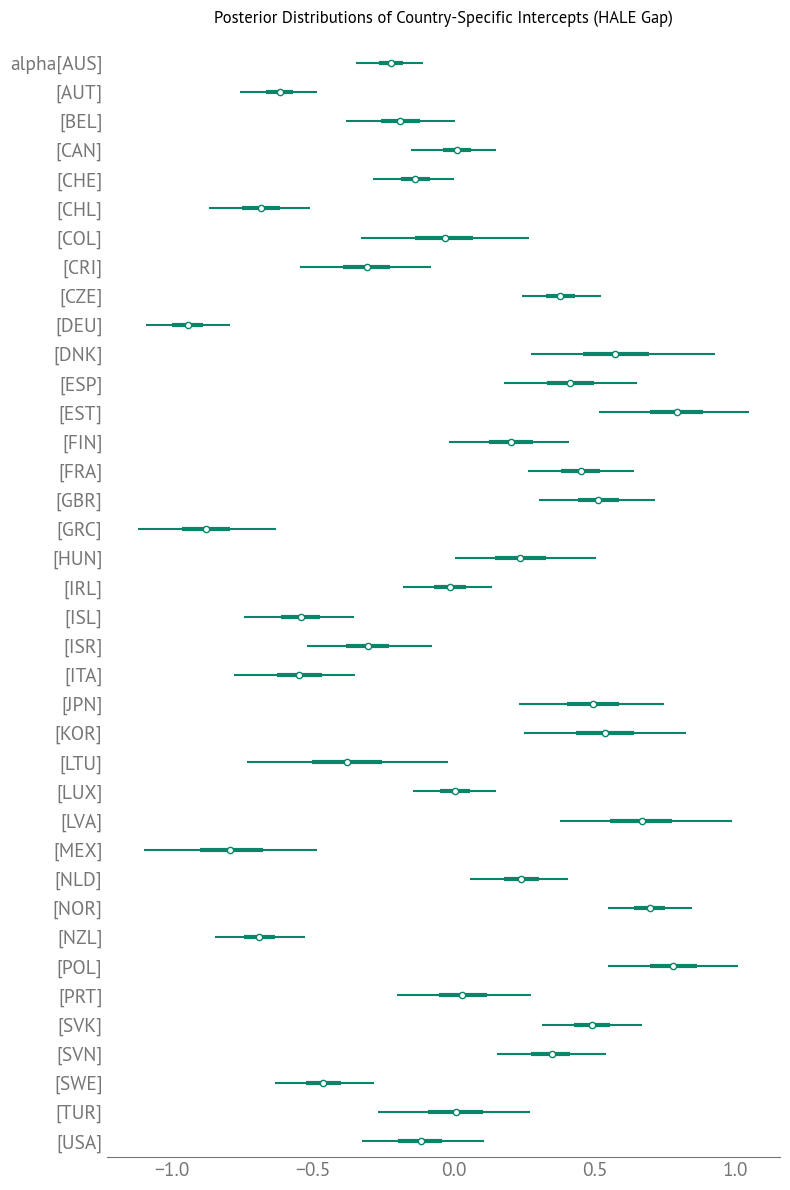

In [39]:
# Plot posterior distributions of country-specific intercepts (alpha) (HALE)
az.plot_forest(trace_hale, var_names=["alpha"], combined=True, figsize=(8, 12))
plt.title("Posterior Distributions of Country-Specific Intercepts (HALE Gap)")
plt.tight_layout()
plt.show()

### Correlations

In [40]:
# Extract posterior samples for beta coefficients (if not already done)
beta_extracted_hale = az.extract(trace_hale)
beta_samples_df_hale = pd.DataFrame(
    beta_extracted_hale['beta'].T,
    columns=data_hale["meta"]["predictors"]
)

# Compute correlation matrix for beta coefficients
beta_corr_hale = beta_samples_df_hale.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
beta_corr_triu = np.triu(beta_corr_hale.values, k=1)
beta_corr_long = []
for i in range(len(beta_corr_hale.index)):
    for j in range(i + 1, len(beta_corr_hale.columns)):
        if not np.isnan(beta_corr_triu[i, j]):
            beta_corr_long.append({
                'Predictor1': beta_corr_hale.index[i],
                'Predictor2': beta_corr_hale.columns[j],
                'Correlation': beta_corr_triu[i, j]
            })

beta_corr_df_hale = pd.DataFrame(beta_corr_long)
beta_corr_df_hale['Abs_Correlation'] = beta_corr_df_hale['Correlation'].abs()
beta_corr_top10_hale = beta_corr_df_hale.nlargest(10, 'Abs_Correlation')[
    ['Predictor1', 'Predictor2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among beta coefficients (HALE):")
beta_corr_top10_hale

Top 10 correlations among beta coefficients (HALE):


,Predictor1,Predictor2,Correlation
70,Mid_Homicide,Gap_Homicide,-0.998363
0,Mid_Alcohol,Gap_Alcohol,-0.973088
184,Mid_LiverDisease,Gap_LiverDisease,-0.950206
99,Mid_RoadTraffic,Gap_RoadTraffic,-0.943675
37,Mid_Suicide,Gap_Suicide,-0.884653
18,Mid_Alcohol,Gap_UnintentionalInjury,-0.448492
167,Mid_Neoplasms,Mid_UnintentionalInjury,-0.431336
162,Mid_Neoplasms,Gap_Neoplasms,-0.410386
36,Gap_Alcohol,Gap_UnintentionalInjury,0.390487
127,Mid_Cardiovascular,Mid_Neoplasms,-0.372671


In [41]:
# Write beta correlations table to HTML
write_html_table(beta_corr_top10_hale, 'jb/tables/beta_correlations_top10_hale.html')

In [42]:
# Extract posterior samples for alpha coefficients (country intercepts)
alpha_extracted_hale = az.extract(trace_hale)
alpha_samples_df_hale = pd.DataFrame(
    alpha_extracted_hale['alpha'].T,
    columns=data_hale["meta"]["countries"]
)

# Compute correlation matrix for alpha coefficients
alpha_corr_hale = alpha_samples_df_hale.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
alpha_corr_triu = np.triu(alpha_corr_hale.values, k=1)
alpha_corr_long = []
for i in range(len(alpha_corr_hale.index)):
    for j in range(i + 1, len(alpha_corr_hale.columns)):
        if not np.isnan(alpha_corr_triu[i, j]):
            alpha_corr_long.append({
                'Country1': alpha_corr_hale.index[i],
                'Country2': alpha_corr_hale.columns[j],
                'Correlation': alpha_corr_triu[i, j]
            })

alpha_corr_df_hale = pd.DataFrame(alpha_corr_long)
alpha_corr_df_hale['Abs_Correlation'] = alpha_corr_df_hale['Correlation'].abs()
alpha_corr_top10_hale = alpha_corr_df_hale.nlargest(10, 'Abs_Correlation')[
    ['Country1', 'Country2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among alpha coefficients (country intercepts, HALE):")
alpha_corr_top10_hale

Top 10 correlations among alpha coefficients (country intercepts, HALE):


,Country1,Country2,Correlation
391,EST,LVA,0.722806
207,COL,CRI,0.675544
389,EST,LTU,0.673825
176,CHL,CRI,0.668722
613,LTU,LVA,0.667810
196,CHL,MEX,0.647428
495,HUN,ISR,-0.647143
257,CRI,MEX,0.624399
643,LVA,SVK,0.614755
266,CRI,TUR,0.596931


In [43]:
# Write alpha correlations table to HTML
write_html_table(alpha_corr_top10_hale, 'jb/tables/alpha_correlations_top10_hale.html')

### Comparison with Cross-Sectional Elastic Net Model

In [49]:
def plot_bayesian_elasticnet_comparison(beta_samples_df, elastic_net_coefs, common_predictors,
                                        title, output_filename, n_rows=5, n_cols=4):
    """
    Create comparison visualization showing posterior distributions vs Elastic Net coefficients.
    
    Parameters
    ----------
    beta_samples_df : pd.DataFrame
        DataFrame with posterior samples (columns = predictors, rows = samples)
    elastic_net_coefs : pd.DataFrame
        DataFrame with Elastic Net coefficients (indexed by predictor)
    common_predictors : list
        List of common predictors between Bayesian and Elastic Net models
    title : str
        Title for the plot
    output_filename : str
        Filename to save the figure
    n_rows : int
        Number of rows in subplot grid (default: 5)
    n_cols : int
        Number of columns in subplot grid (default: 4)
    """
    n_plots = n_rows * n_cols
    
    # Select predictors to plot (prioritize those with non-zero EN coefficients)
    predictors_to_plot = elastic_net_coefs.loc[common_predictors].sort_values(
        'ElasticNet_Coefficient', key=abs, ascending=False
    ).head(n_plots).index.tolist()
    
    # If we have fewer predictors than subplots, use all predictors
    if len(common_predictors) < n_plots:
        predictors_to_plot = common_predictors
        n_rows = int(np.ceil(len(predictors_to_plot) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 20))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()
    
    for i, pred in enumerate(predictors_to_plot):
        ax = axes[i]
        
        # Get posterior samples for this predictor
        posterior_samples = beta_samples_df[pred].values
        
        # Get Elastic Net coefficient
        en_coef = elastic_net_coefs.loc[pred, 'ElasticNet_Coefficient']
        
        # Plot posterior distribution with HDI using az.plot_dist
        az.plot_dist(posterior_samples, ax=ax, color=AIBM_COLORS['crimson'])
        
        # Add vertical line for Elastic Net coefficient
        ax.axvline(en_coef, color=AIBM_COLORS['blue'], linestyle='--', linewidth=2, 
                   label=f'Elastic Net: {en_coef:.3f}')
        
        # Add vertical line for posterior mean
        posterior_mean = posterior_samples.mean()
        ax.axvline(posterior_mean, color=AIBM_COLORS['green'], linestyle='-', linewidth=2,
                   label=f'Posterior mean: {posterior_mean:.3f}')
        
        ax.set_xlabel('Coefficient')
        ax.set_ylabel('Density')
        ax.set_title(pred, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(predictors_to_plot), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

In [50]:
# Load Elastic Net coefficients from cross-sectional model
cutoff_year = 2019  # Match the cutoff year used in cross-sectional analysis
elastic_net_coefs_hale = pd.read_csv(f'../data/elasticnet_coefficients_hale_{cutoff_year}.csv')
elastic_net_coefs_hale = elastic_net_coefs_hale.set_index('Predictor')

print(f"Loaded {len(elastic_net_coefs_hale)} Elastic Net coefficients for HALE")
print(f"Bayesian model has {len(data_hale['meta']['predictors'])} predictors")

Loaded 22 Elastic Net coefficients for HALE
Bayesian model has 20 predictors


In [51]:
# Extract posterior samples for beta coefficients
beta_extracted_hale = az.extract(trace_hale)

# Create DataFrame with predictor names
beta_samples_df_hale = pd.DataFrame(
    beta_extracted_hale['beta'].T,
    columns=data_hale["meta"]["predictors"]
)

print(f"Posterior samples shape: {beta_samples_df_hale.shape}")

Posterior samples shape: (4000, 20)


In [52]:
# Match predictors between Bayesian and Elastic Net models
# Find common predictors
common_predictors = set(beta_samples_df_hale.columns) & set(elastic_net_coefs_hale.index)
common_predictors = sorted(list(common_predictors))

print(f"Common predictors: {len(common_predictors)}")
print(f"Predictors only in Bayesian model: {len(set(beta_samples_df_hale.columns) - set(elastic_net_coefs_hale.index))}")
print(f"Predictors only in Elastic Net model: {len(set(elastic_net_coefs_hale.index) - set(beta_samples_df_hale.columns))}")

Common predictors: 20
Predictors only in Bayesian model: 0
Predictors only in Elastic Net model: 2


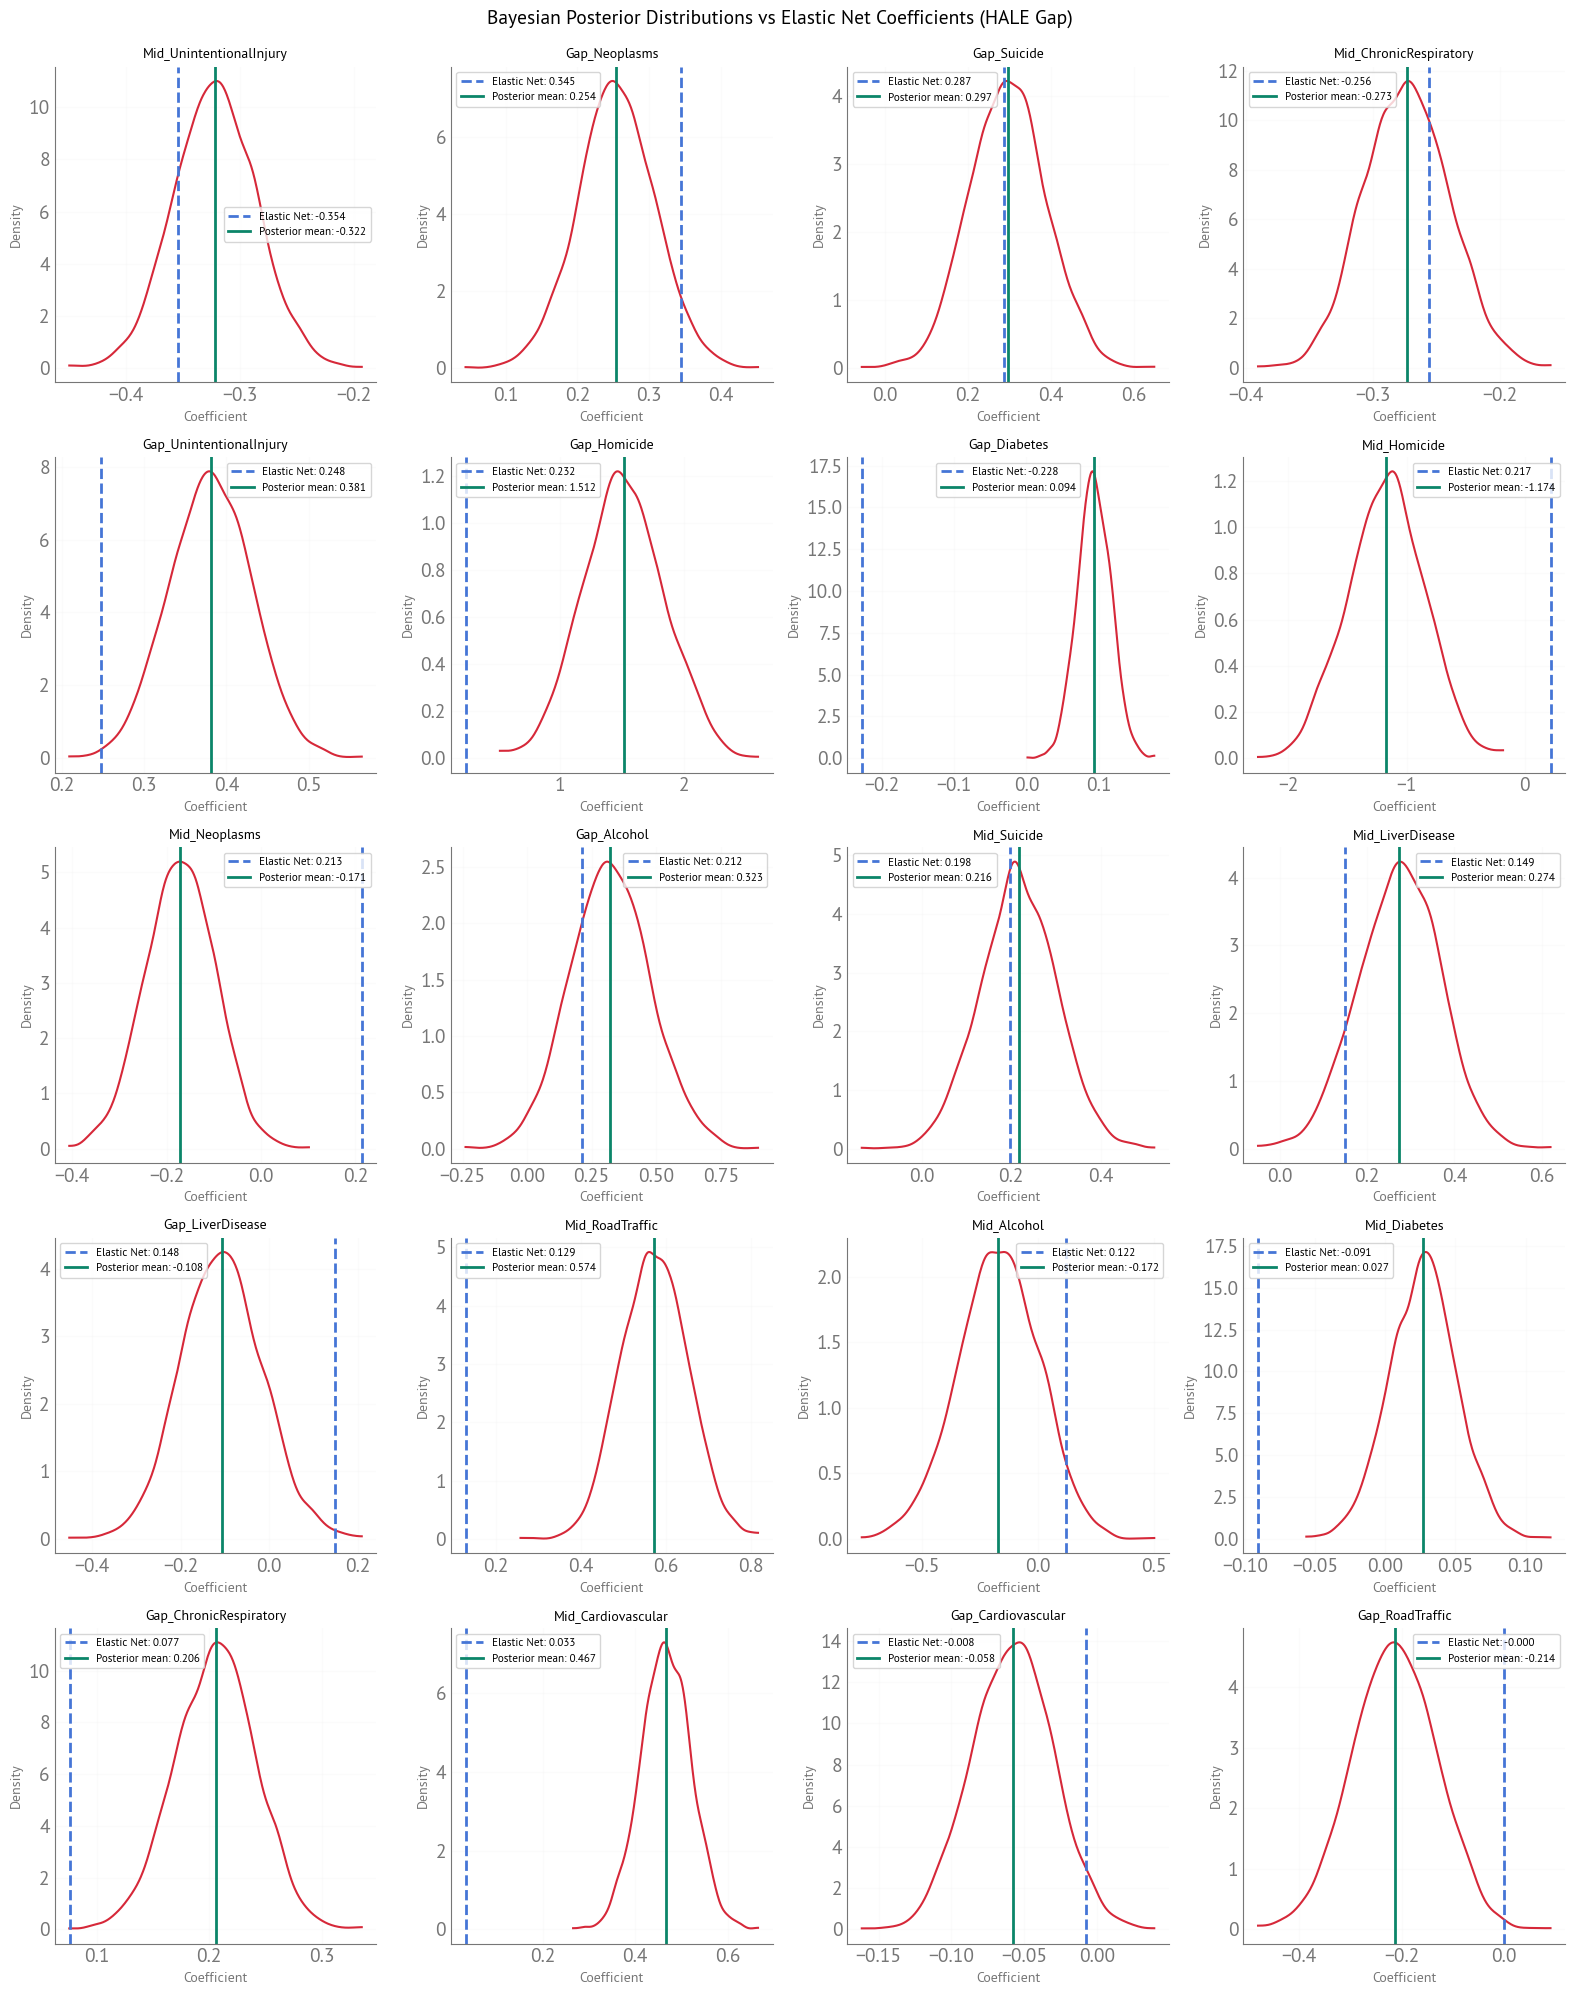

In [53]:
# Create comparison visualization using the function
plot_bayesian_elasticnet_comparison(
    beta_samples_df_hale,
    elastic_net_coefs_hale,
    common_predictors,
    title='Bayesian Posterior Distributions vs Elastic Net Coefficients (HALE Gap)',
    output_filename='jb/figs/bayesian_elasticnet_comparison_hale.png'
)

In [54]:
# Create summary comparison table
comparison_table_hale = pd.DataFrame({
    'Predictor': common_predictors,
    'ElasticNet_Coefficient': [elastic_net_coefs_hale.loc[p, 'ElasticNet_Coefficient'] for p in common_predictors],
    'Bayesian_Mean': [beta_samples_df_hale[p].mean() for p in common_predictors],
    'Bayesian_Std': [beta_samples_df_hale[p].std() for p in common_predictors],
    'Bayesian_CI_Lower': [np.percentile(beta_samples_df_hale[p].values, 2.5) for p in common_predictors],
    'Bayesian_CI_Upper': [np.percentile(beta_samples_df_hale[p].values, 97.5) for p in common_predictors],
    'Difference': [beta_samples_df_hale[p].mean() - elastic_net_coefs_hale.loc[p, 'ElasticNet_Coefficient'] 
                   for p in common_predictors]
})

comparison_table_hale = comparison_table_hale.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
comparison_table_hale.head(20)

,Predictor,ElasticNet_Coefficient,Bayesian_Mean,Bayesian_Std,Bayesian_CI_Lower,Bayesian_CI_Upper,Difference
19,Mid_UnintentionalInjury,-0.354215,-0.321824,0.035952,-0.391098,-0.249730,0.032391
6,Gap_Neoplasms,0.344777,0.254093,0.053545,0.148836,0.359825,-0.090684
8,Gap_Suicide,0.287401,0.296837,0.092352,0.119764,0.479179,0.009436
12,Mid_ChronicRespiratory,-0.255945,-0.273302,0.033536,-0.337408,-0.205871,-0.017357
9,Gap_UnintentionalInjury,0.247515,0.380699,0.049917,0.284922,0.477543,0.133184
4,Gap_Homicide,0.231818,1.512230,0.327989,0.876916,2.151080,1.280412
3,Gap_Diabetes,-0.228147,0.093692,0.023290,0.048228,0.138937,0.321839
14,Mid_Homicide,0.217270,-1.174209,0.324758,-1.802131,-0.549829,-1.391479
16,Mid_Neoplasms,0.213345,-0.171268,0.073779,-0.317376,-0.030879,-0.384614
0,Gap_Alcohol,0.211845,0.322725,0.154062,0.023624,0.635843,0.110880


## Life Expectancy Gap Model

### Build Model

In [55]:
# Build model for Life Expectancy gap
model_le = build_random_intercept_panel_model(data_le)
model_le

   mu_alpha ~ Normal(0, 5)
sigma_alpha ~ HalfNormal(0, 1)
  alpha_raw ~ Normal(0, 1)
       beta ~ Normal(0, 1)
      sigma ~ HalfNormal(0, 1)
      alpha ~ Deterministic(f(alpha_raw, mu_alpha, sigma_alpha))
         mu ~ Deterministic(f(beta, alpha_raw, mu_alpha, sigma_alpha))
      y_obs ~ Normal(mu, sigma)

### Sample from Posterior

In [56]:
# Sample from Life Expectancy model
with model_le:
    trace_le = pm.sample(
        nuts_sampler='nutpie'
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.13,255
,2000,0,0.13,63
,2000,0,0.11,127
,2000,0,0.14,255


### Model Diagnostics

Check convergence and sampling quality:

In [57]:
# Life Expectancy model diagnostics
az.summary(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,0.006,0.106,-0.188,0.207,0.003,0.002,1644.0,2116.0,1.0
sigma_alpha,0.649,0.086,0.492,0.805,0.002,0.001,1615.0,2581.0,1.0
sigma,0.216,0.006,0.205,0.227,0.000,0.000,3778.0,2298.0,1.0
beta[Mid_Alcohol],-0.247,0.200,-0.631,0.112,0.005,0.004,1691.0,2269.0,1.0
beta[Gap_Alcohol],0.397,0.176,0.052,0.706,0.004,0.003,1736.0,2304.0,1.0
beta[Mid_Suicide],0.215,0.096,0.035,0.387,0.002,0.001,3298.0,3229.0,1.0
beta[Gap_Suicide],0.344,0.103,0.150,0.536,0.002,0.001,3644.0,3303.0,1.0
beta[Mid_Homicide],-1.434,0.347,-2.090,-0.802,0.010,0.006,1190.0,1691.0,1.0
beta[Gap_Homicide],1.832,0.351,1.155,2.451,0.010,0.006,1188.0,1673.0,1.0
beta[Mid_RoadTraffic],0.563,0.089,0.398,0.722,0.002,0.001,2966.0,2720.0,1.0


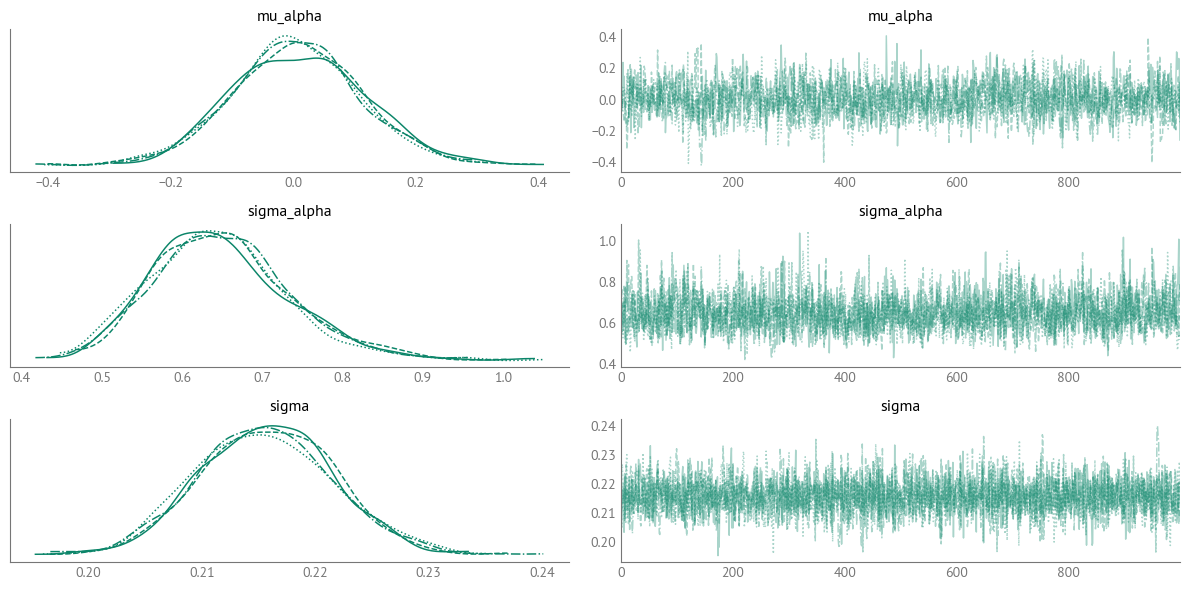

In [58]:
# Plot trace plots for key parameters (Life Expectancy)
az.plot_trace(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma"], compact=True)
plt.tight_layout()
plt.show()

### Posterior Analysis

Extract and analyze posterior distributions:

In [59]:
# Extract posterior means and credible intervals for beta coefficients (Life Expectancy)
beta_summary_le = az.summary(trace_le, var_names=["beta"])
beta_summary_le.index = data_le["meta"]["predictors"]
beta_summary_le

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Mid_Alcohol,-0.247,0.200,-0.631,0.112,0.005,0.004,1691.0,2269.0,1.0
Gap_Alcohol,0.397,0.176,0.052,0.706,0.004,0.003,1736.0,2304.0,1.0
Mid_Suicide,0.215,0.096,0.035,0.387,0.002,0.001,3298.0,3229.0,1.0
Gap_Suicide,0.344,0.103,0.150,0.536,0.002,0.001,3644.0,3303.0,1.0
Mid_Homicide,-1.434,0.347,-2.090,-0.802,0.010,0.006,1190.0,1691.0,1.0
Gap_Homicide,1.832,0.351,1.155,2.451,0.010,0.006,1188.0,1673.0,1.0
Mid_RoadTraffic,0.563,0.089,0.398,0.722,0.002,0.001,2966.0,2720.0,1.0
Gap_RoadTraffic,-0.253,0.093,-0.424,-0.080,0.002,0.002,3244.0,2446.0,1.0
Mid_Cardiovascular,0.604,0.063,0.487,0.720,0.001,0.001,5188.0,3038.0,1.0
Gap_Cardiovascular,0.021,0.032,-0.043,0.075,0.000,0.000,4469.0,3434.0,1.0


In [60]:
# Write beta coefficients table to HTML
beta_summary_le_formatted = beta_summary_le.reset_index().rename(columns={'index': 'Predictor'})
write_html_table(beta_summary_le_formatted, 'jb/tables/beta_coefficients_le.html')

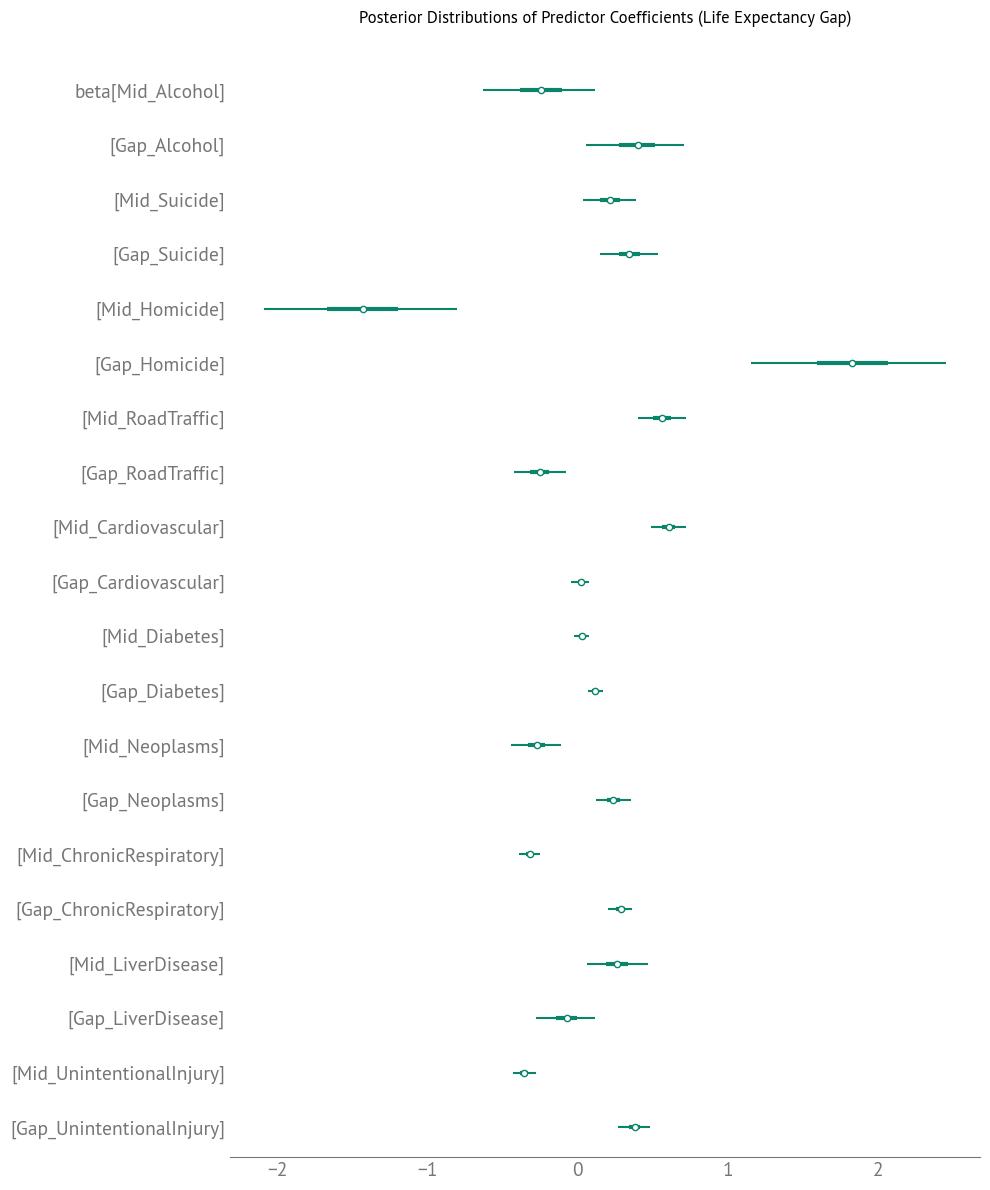

In [61]:
# Plot posterior distributions of beta coefficients (Life Expectancy)
az.plot_forest(trace_le, var_names=["beta"], combined=True, figsize=(10, 12))
plt.title("Posterior Distributions of Predictor Coefficients (Life Expectancy Gap)")
plt.tight_layout()
plt.show()

In [62]:
# Extract posterior means and credible intervals for alpha coefficients (country intercepts, Life Expectancy)
alpha_summary_le = az.summary(trace_le, var_names=["alpha"])
alpha_summary_le.index = data_le["meta"]["countries"]
alpha_summary_le

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
AUS,-0.526,0.073,-0.669,-0.392,0.001,0.001,4363.0,3123.0,1.0
AUT,-0.524,0.082,-0.668,-0.363,0.001,0.001,5303.0,3647.0,1.0
BEL,0.290,0.119,0.078,0.515,0.002,0.002,4313.0,3260.0,1.0
CAN,-0.248,0.093,-0.425,-0.078,0.002,0.001,3481.0,2866.0,1.0
CHE,-0.142,0.086,-0.301,0.021,0.001,0.001,4152.0,3786.0,1.0
CHL,-0.361,0.114,-0.572,-0.151,0.002,0.001,3733.0,3389.0,1.0
COL,-1.016,0.187,-1.386,-0.676,0.003,0.003,3527.0,3049.0,1.0
CRI,-0.781,0.145,-1.048,-0.498,0.002,0.002,3684.0,3447.0,1.0
CZE,-0.160,0.086,-0.331,-0.006,0.001,0.001,4782.0,3462.0,1.0
DEU,-0.200,0.093,-0.374,-0.027,0.002,0.001,3474.0,3245.0,1.0


In [63]:
# Write alpha coefficients table to HTML
alpha_summary_le_formatted = alpha_summary_le.reset_index().rename(columns={'index': 'Country'})
write_html_table(alpha_summary_le_formatted, 'jb/tables/alpha_coefficients_le.html')

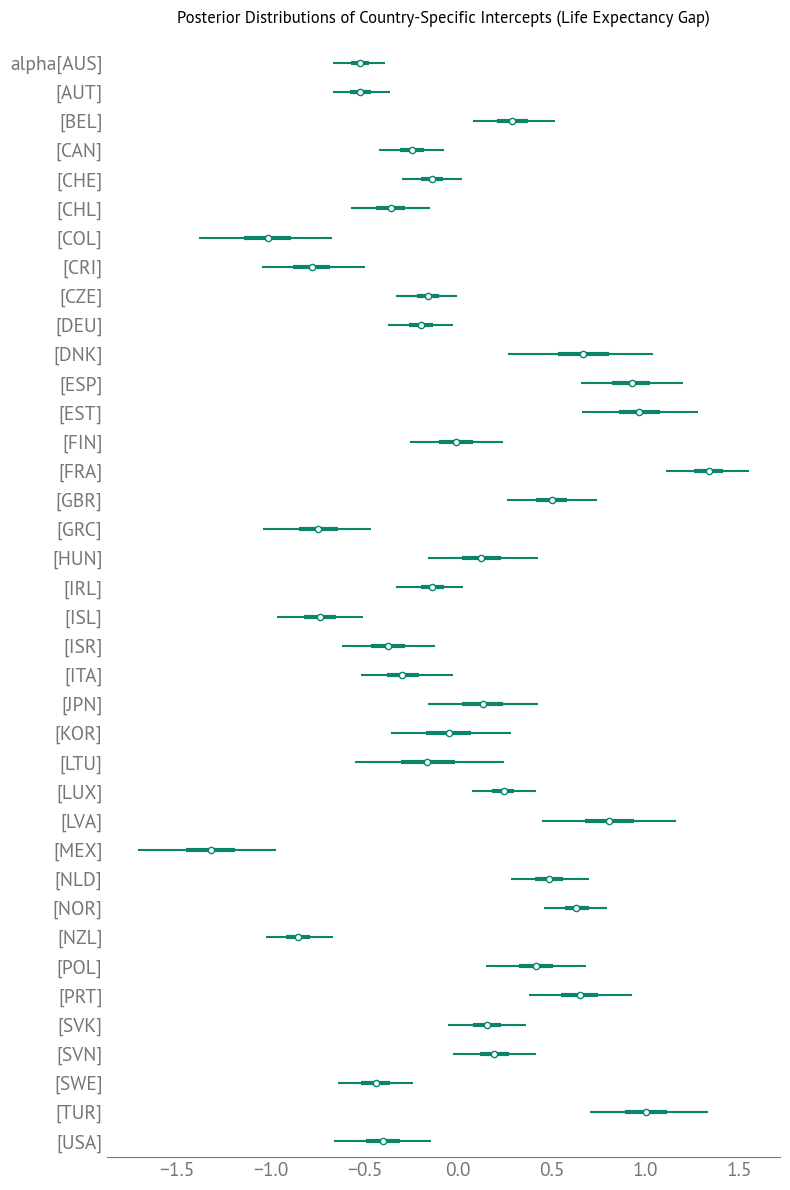

In [64]:
# Plot posterior distributions of country-specific intercepts (alpha) (Life Expectancy)
az.plot_forest(trace_le, var_names=["alpha"], combined=True, figsize=(8, 12))
plt.title("Posterior Distributions of Country-Specific Intercepts (Life Expectancy Gap)")
plt.tight_layout()
plt.show()

### Correlations

In [65]:
# Extract posterior samples for beta coefficients (if not already done)
beta_extracted_le = az.extract(trace_le)
beta_samples_df_le = pd.DataFrame(
    beta_extracted_le['beta'].T,
    columns=data_le["meta"]["predictors"]
)

# Compute correlation matrix for beta coefficients
beta_corr_le = beta_samples_df_le.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
beta_corr_triu = np.triu(beta_corr_le.values, k=1)
beta_corr_long = []
for i in range(len(beta_corr_le.index)):
    for j in range(i + 1, len(beta_corr_le.columns)):
        if not np.isnan(beta_corr_triu[i, j]):
            beta_corr_long.append({
                'Predictor1': beta_corr_le.index[i],
                'Predictor2': beta_corr_le.columns[j],
                'Correlation': beta_corr_triu[i, j]
            })

beta_corr_df_le = pd.DataFrame(beta_corr_long)
beta_corr_df_le['Abs_Correlation'] = beta_corr_df_le['Correlation'].abs()
beta_corr_top10_le = beta_corr_df_le.nlargest(10, 'Abs_Correlation')[
    ['Predictor1', 'Predictor2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among beta coefficients (Life Expectancy):")
beta_corr_top10_le

Top 10 correlations among beta coefficients (Life Expectancy):


,Predictor1,Predictor2,Correlation
70,Mid_Homicide,Gap_Homicide,-0.998058
0,Mid_Alcohol,Gap_Alcohol,-0.974001
184,Mid_LiverDisease,Gap_LiverDisease,-0.952260
99,Mid_RoadTraffic,Gap_RoadTraffic,-0.940858
37,Mid_Suicide,Gap_Suicide,-0.888508
18,Mid_Alcohol,Gap_UnintentionalInjury,-0.452709
167,Mid_Neoplasms,Mid_UnintentionalInjury,-0.447392
162,Mid_Neoplasms,Gap_Neoplasms,-0.428811
36,Gap_Alcohol,Gap_UnintentionalInjury,0.395837
138,Gap_Cardiovascular,Gap_Neoplasms,-0.387712


In [66]:
# Write beta correlations table to HTML
write_html_table(beta_corr_top10_le, 'jb/tables/beta_correlations_top10_le.html')

In [67]:
# Extract posterior samples for alpha coefficients (country intercepts)
alpha_extracted_le = az.extract(trace_le)
alpha_samples_df_le = pd.DataFrame(
    alpha_extracted_le['alpha'].T,
    columns=data_le["meta"]["countries"]
)

# Compute correlation matrix for alpha coefficients
alpha_corr_le = alpha_samples_df_le.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
alpha_corr_triu = np.triu(alpha_corr_le.values, k=1)
alpha_corr_long = []
for i in range(len(alpha_corr_le.index)):
    for j in range(i + 1, len(alpha_corr_le.columns)):
        if not np.isnan(alpha_corr_triu[i, j]):
            alpha_corr_long.append({
                'Country1': alpha_corr_le.index[i],
                'Country2': alpha_corr_le.columns[j],
                'Correlation': alpha_corr_triu[i, j]
            })

alpha_corr_df_le = pd.DataFrame(alpha_corr_long)
alpha_corr_df_le['Abs_Correlation'] = alpha_corr_df_le['Correlation'].abs()
alpha_corr_top10_le = alpha_corr_df_le.nlargest(10, 'Abs_Correlation')[
    ['Country1', 'Country2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among alpha coefficients (country intercepts, Life Expectancy):")
alpha_corr_top10_le

Top 10 correlations among alpha coefficients (country intercepts, Life Expectancy):


,Country1,Country2,Correlation
391,EST,LVA,0.733115
176,CHL,CRI,0.706603
207,COL,CRI,0.697436
389,EST,LTU,0.686308
613,LTU,LVA,0.685412
196,CHL,MEX,0.671384
495,HUN,ISR,-0.662607
257,CRI,MEX,0.653463
643,LVA,SVK,0.621682
329,DNK,GBR,0.617288


In [68]:
# Write alpha correlations table to HTML
write_html_table(alpha_corr_top10_le, 'jb/tables/alpha_correlations_top10_le.html')

### Comparison with Cross-Sectional Elastic Net Model

In [69]:
# Load Elastic Net coefficients from cross-sectional model
cutoff_year = 2019  # Match the cutoff year used in cross-sectional analysis
elastic_net_coefs_le = pd.read_csv(f'../data/elasticnet_coefficients_le_{cutoff_year}.csv')
elastic_net_coefs_le = elastic_net_coefs_le.set_index('Predictor')

print(f"Loaded {len(elastic_net_coefs_le)} Elastic Net coefficients for Life Expectancy")
print(f"Bayesian model has {len(data_le['meta']['predictors'])} predictors")

Loaded 22 Elastic Net coefficients for Life Expectancy
Bayesian model has 20 predictors


In [70]:
# Extract posterior samples for beta coefficients
beta_extracted_le = az.extract(trace_le)

# Create DataFrame with predictor names
beta_samples_df_le = pd.DataFrame(
    beta_extracted_le['beta'].T,
    columns=data_le["meta"]["predictors"]
)

print(f"Posterior samples shape: {beta_samples_df_le.shape}")

Posterior samples shape: (4000, 20)


In [71]:
# Match predictors between Bayesian and Elastic Net models
# Find common predictors
common_predictors_le = set(beta_samples_df_le.columns) & set(elastic_net_coefs_le.index)
common_predictors_le = sorted(list(common_predictors_le))

print(f"Common predictors: {len(common_predictors_le)}")
print(f"Predictors only in Bayesian model: {len(set(beta_samples_df_le.columns) - set(elastic_net_coefs_le.index))}")
print(f"Predictors only in Elastic Net model: {len(set(elastic_net_coefs_le.index) - set(beta_samples_df_le.columns))}")

Common predictors: 20
Predictors only in Bayesian model: 0
Predictors only in Elastic Net model: 2


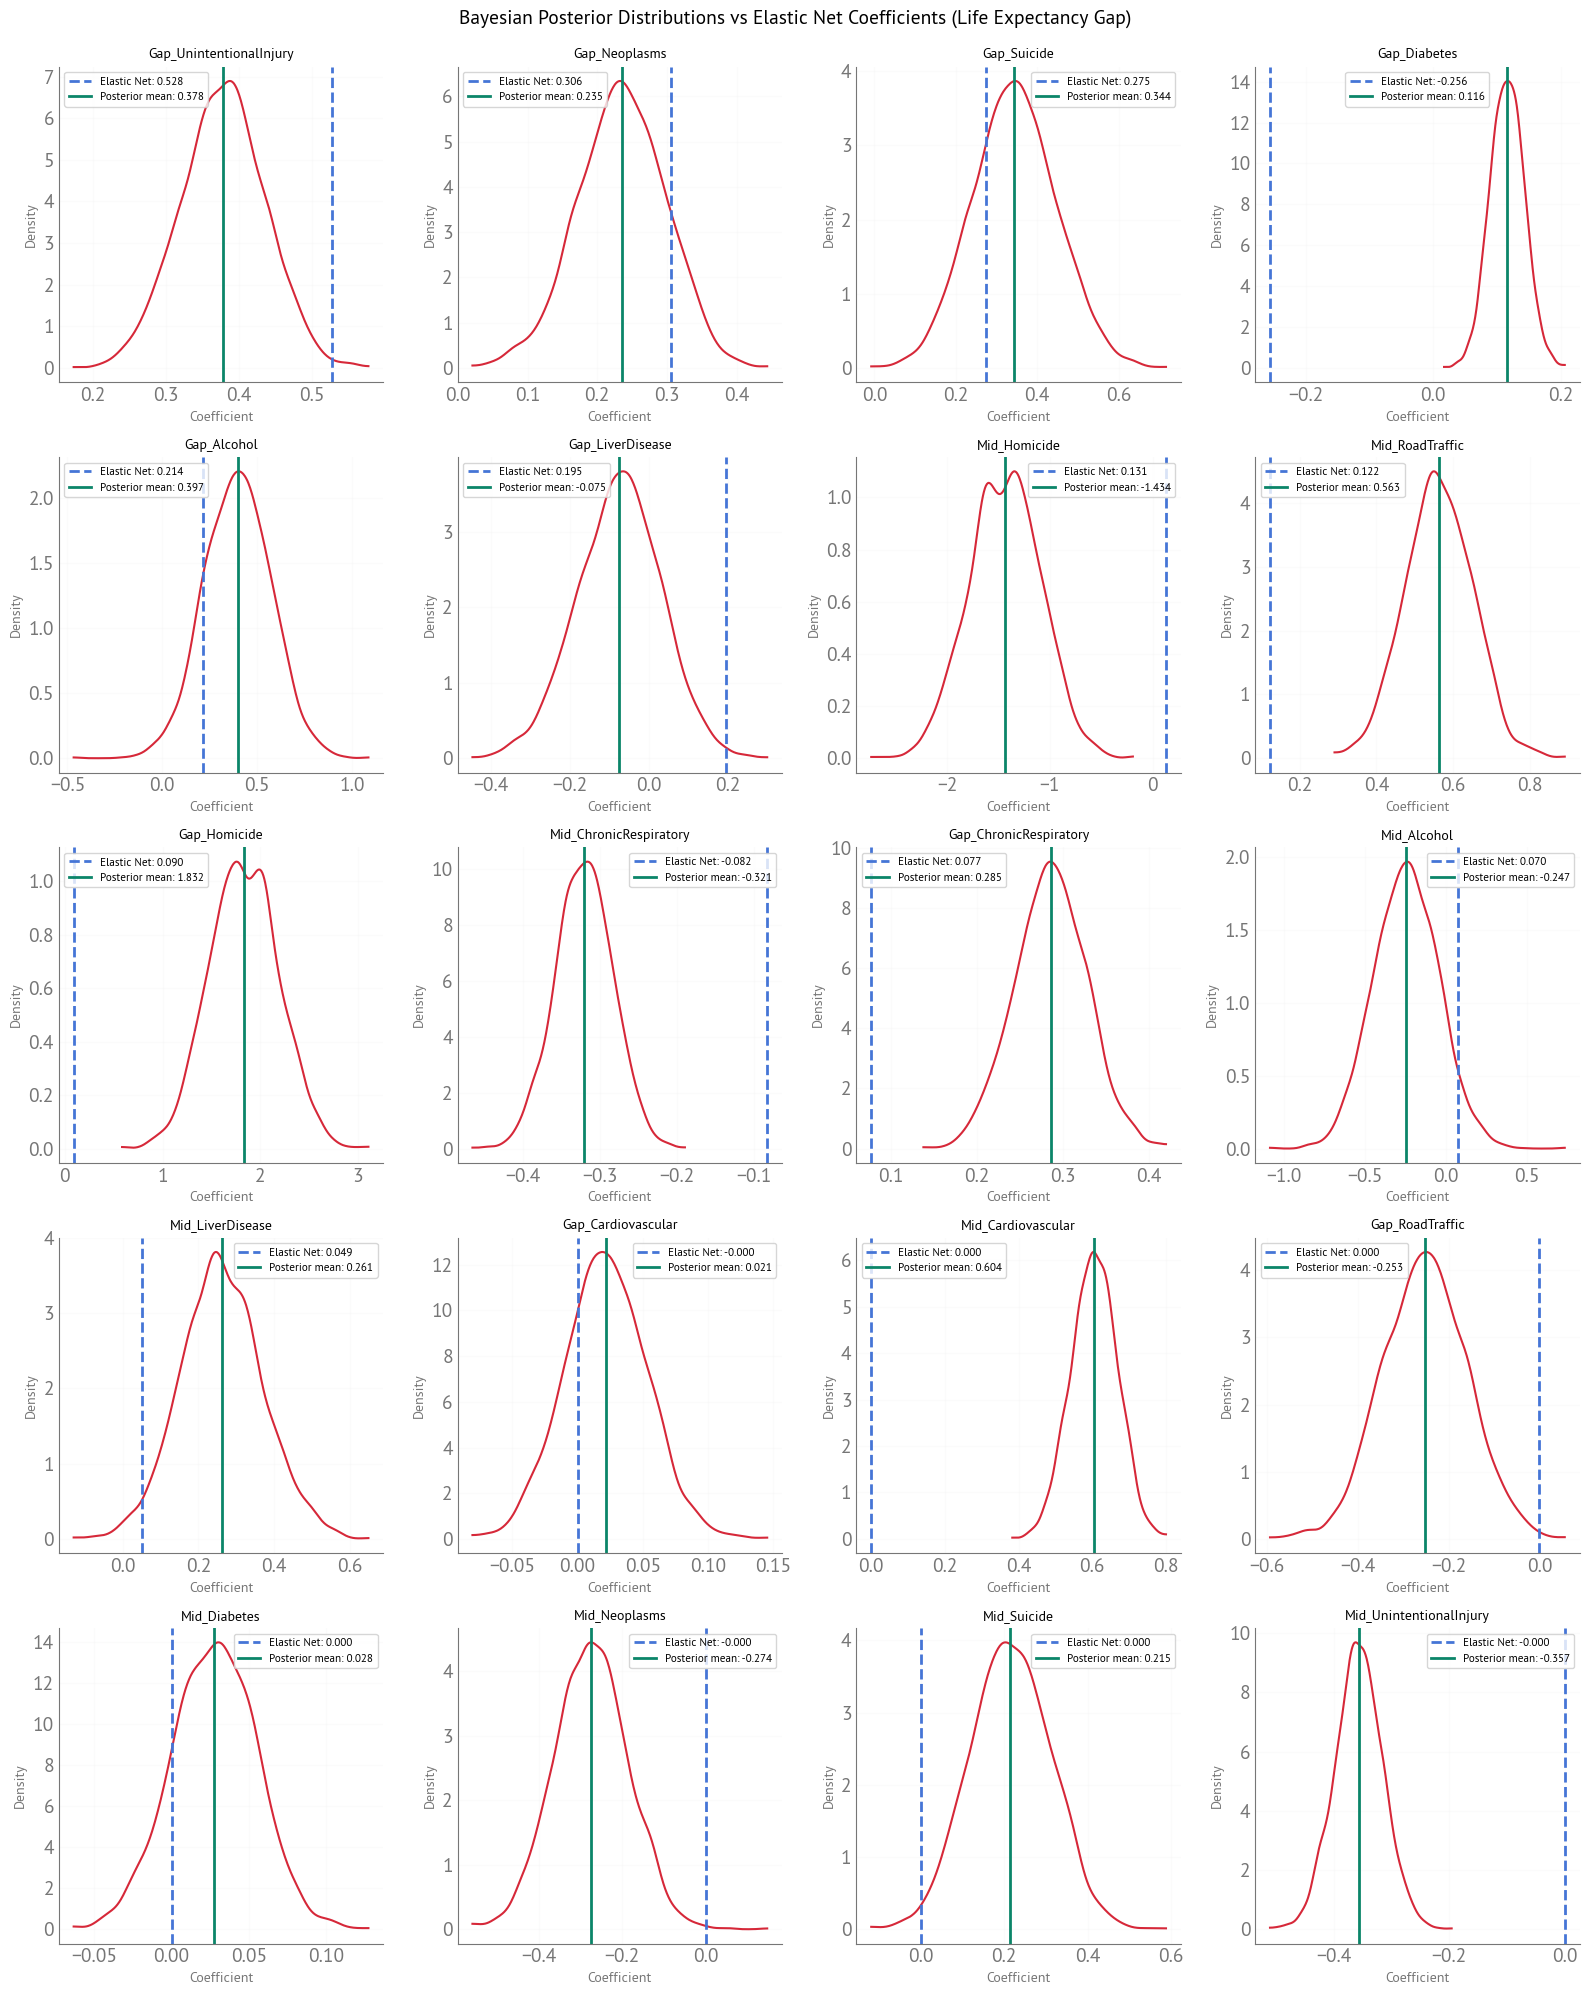

In [72]:
# Create comparison visualization using the function
plot_bayesian_elasticnet_comparison(
    beta_samples_df_le,
    elastic_net_coefs_le,
    common_predictors_le,
    title='Bayesian Posterior Distributions vs Elastic Net Coefficients (Life Expectancy Gap)',
    output_filename='jb/figs/bayesian_elasticnet_comparison_le.png'
)

In [73]:
# Create summary comparison table
comparison_table_le = pd.DataFrame({
    'Predictor': common_predictors_le,
    'ElasticNet_Coefficient': [elastic_net_coefs_le.loc[p, 'ElasticNet_Coefficient'] for p in common_predictors_le],
    'Bayesian_Mean': [beta_samples_df_le[p].mean() for p in common_predictors_le],
    'Bayesian_Std': [beta_samples_df_le[p].std() for p in common_predictors_le],
    'Bayesian_CI_Lower': [np.percentile(beta_samples_df_le[p].values, 2.5) for p in common_predictors_le],
    'Bayesian_CI_Upper': [np.percentile(beta_samples_df_le[p].values, 97.5) for p in common_predictors_le],
    'Difference': [beta_samples_df_le[p].mean() - elastic_net_coefs_le.loc[p, 'ElasticNet_Coefficient'] 
                   for p in common_predictors_le]
})

comparison_table_le = comparison_table_le.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
comparison_table_le.head(20)

,Predictor,ElasticNet_Coefficient,Bayesian_Mean,Bayesian_Std,Bayesian_CI_Lower,Bayesian_CI_Upper,Difference
9,Gap_UnintentionalInjury,0.528076,0.377910,0.057808,0.263994,0.488395,-0.150165
6,Gap_Neoplasms,0.306021,0.234826,0.063094,0.105568,0.353174,-0.071195
8,Gap_Suicide,0.274845,0.343620,0.102705,0.144987,0.546784,0.068774
3,Gap_Diabetes,-0.256190,0.116222,0.026924,0.063708,0.168709,0.372412
0,Gap_Alcohol,0.213706,0.397072,0.175755,0.053131,0.740076,0.183366
5,Gap_LiverDisease,0.195095,-0.075363,0.106045,-0.289405,0.128302,-0.270458
14,Mid_Homicide,0.131171,-1.434378,0.347256,-2.115066,-0.767269,-1.565550
17,Mid_RoadTraffic,0.122016,0.562679,0.088770,0.389521,0.733236,0.440662
4,Gap_Homicide,0.090231,1.831740,0.350820,1.157804,2.520244,1.741510
12,Mid_ChronicRespiratory,-0.082223,-0.320745,0.037655,-0.395120,-0.247895,-0.238523


## Next Steps

- Posterior predictive checks
- Counterfactual analysis with uncertainty quantification
- Model extensions (year fixed effects, AR(1) structure)
- Comparison with cross-sectional Elastic Net results



In [ ]:
from utils import beep

beep()